# Crypto Trader Sentiment Analysis
## Trader Performance vs Market Sentiment (Fear/Greed Index)
**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.


## Part A — Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans'})

# Load datasets
fg_raw   = pd.read_csv('fear_greed_index.csv')
hist_raw = pd.read_csv('historical_data.csv')

print(f"Fear/Greed Index  : {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} columns")
print(f"Trader Data       : {hist_raw.shape[0]:,} rows × {hist_raw.shape[1]} columns")


Fear/Greed Index  : 2,644 rows × 4 columns
Trader Data       : 211,224 rows × 16 columns


In [2]:
# A1 — Missing values & duplicates
print("=== Fear/Greed: Missing Values ===")
print(fg_raw.isnull().sum())
print(f"\nDuplicates: {fg_raw.duplicated().sum()}")

print("\n=== Trader Data: Missing Values ===")
print(hist_raw.isnull().sum())
print(f"\nDuplicates: {hist_raw.duplicated().sum()}")


=== Fear/Greed: Missing Values ===
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

=== Trader Data: Missing Values ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [3]:
# A2 — Parse & align dates
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'])
fg['sentiment'] = fg['classification'].map({
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
})

hist = hist_raw.copy()
hist['date'] = pd.to_datetime(hist['Timestamp IST'].str[:10], format='%d-%m-%Y')

trader_daily = hist.merge(fg[['date', 'classification', 'sentiment', 'value']],
                           on='date', how='inner')

print(f"Merged rows: {trader_daily.shape[0]:,}")
print(f"Date range : {trader_daily['date'].min().date()} → {trader_daily['date'].max().date()}")
print(f"Unique trading days: {trader_daily['date'].nunique()}")


Merged rows: 211,218
Date range : 2023-05-01 → 2025-05-01
Unique trading days: 479


In [4]:
# A3 — Compute key metrics
closes = trader_daily[trader_daily['Closed PnL'] != 0].copy()
closes['win']     = closes['Closed PnL'] > 0
closes['is_long'] = closes['Direction'].str.contains('Long', na=False)
closes['lev_proxy'] = np.where(
    closes['Start Position'].abs() > 10,
    closes['Size USD'] / closes['Start Position'].abs(), np.nan)

# Daily per-trader metrics
daily_trader = closes.groupby(['date', 'Account', 'sentiment', 'classification', 'value']).agg(
    daily_pnl    = ('Closed PnL', 'sum'),
    n_trades     = ('Closed PnL', 'count'),
    win_rate     = ('win', 'mean'),
    avg_size_usd = ('Size USD', 'mean'),
    avg_lev      = ('lev_proxy', 'mean'),
    long_ratio   = ('is_long', 'mean'),
).reset_index()

# Daily market-wide
daily_mkt = closes.groupby(['date', 'sentiment', 'classification', 'value']).agg(
    total_pnl    = ('Closed PnL', 'sum'),
    n_trades     = ('Closed PnL', 'count'),
    win_rate     = ('win', 'mean'),
    avg_size_usd = ('Size USD', 'mean'),
    avg_lev      = ('lev_proxy', 'mean'),
    long_ratio   = ('is_long', 'mean'),
).reset_index()

print(f"Unique traders: {closes['Account'].nunique()}")
print(f"Closing trades analysed: {len(closes):,}")
print("\nSentiment distribution (trading days):")
print(daily_mkt['sentiment'].value_counts())


Unique traders: 32
Closing trades analysed: 104,402

Sentiment distribution (trading days):
sentiment
Greed      275
Fear        89
Neutral     55
Name: count, dtype: int64


## Part B — Analysis
### B1. Does performance differ between Fear vs Greed days?

In [5]:
SENT_ORDER  = ['Fear', 'Neutral', 'Greed']
SENT_COLORS = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#27ae60'}

sent_perf = daily_mkt.groupby('sentiment').agg(
    avg_daily_pnl    = ('total_pnl', 'mean'),
    median_daily_pnl = ('total_pnl', 'median'),
    avg_win_rate     = ('win_rate', 'mean'),
    worst_day_pnl    = ('total_pnl', 'min'),
    days             = ('total_pnl', 'count')
).reindex(SENT_ORDER).round(2)

print("Performance by Sentiment:")
print(sent_perf.to_string())


Performance by Sentiment:
           avg_daily_pnl  median_daily_pnl  avg_win_rate  worst_day_pnl  days
sentiment                                                                    
Fear            46025.46           6978.18          0.85     -122672.00    89
Neutral         23507.65           5306.02          0.79      -10116.88    55
Greed           17692.00           1517.12          0.84     -419020.23   275


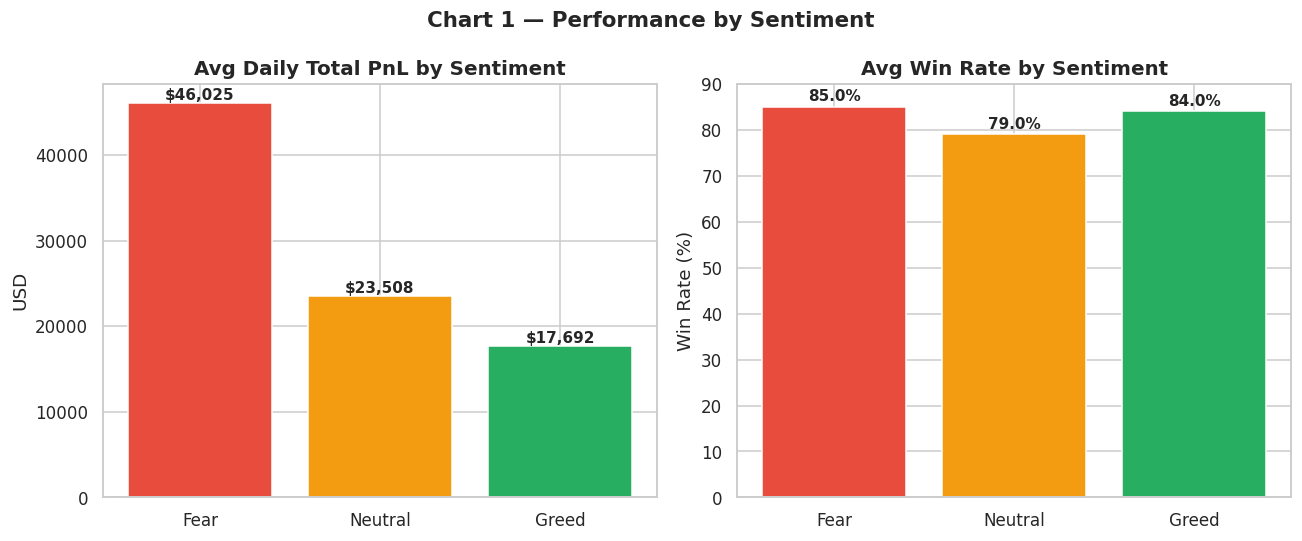

In [6]:
palette = [SENT_COLORS[s] for s in SENT_ORDER]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(SENT_ORDER, sent_perf['avg_daily_pnl'], color=palette, edgecolor='white')
axes[0].set_title('Avg Daily Total PnL by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, sent_perf['avg_daily_pnl']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(SENT_ORDER, sent_perf['avg_win_rate']*100, color=palette, edgecolor='white')
axes[1].set_title('Avg Win Rate by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 90)
for bar, val in zip(bars2, sent_perf['avg_win_rate']*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Chart 1 — Performance by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart1_pnl_winrate_sentiment.png', bbox_inches='tight')
plt.show()


### B2. Do traders change behavior based on sentiment?

In [7]:
bhv = daily_trader.groupby('sentiment').agg(
    avg_trades     = ('n_trades', 'mean'),
    avg_lev        = ('avg_lev', 'mean'),
    avg_long_ratio = ('long_ratio', 'mean'),
    avg_size_usd   = ('avg_size_usd', 'mean'),
).reindex(SENT_ORDER).round(3)

print("Trader Behaviour by Sentiment:")
print(bhv.to_string())


Trader Behaviour by Sentiment:
           avg_trades  avg_lev  avg_long_ratio  avg_size_usd
sentiment                                                   
Fear           70.304  321.608           0.481     11593.063
Neutral        65.793  145.286           0.483      8574.103
Greed          54.537  113.869           0.415      6822.258


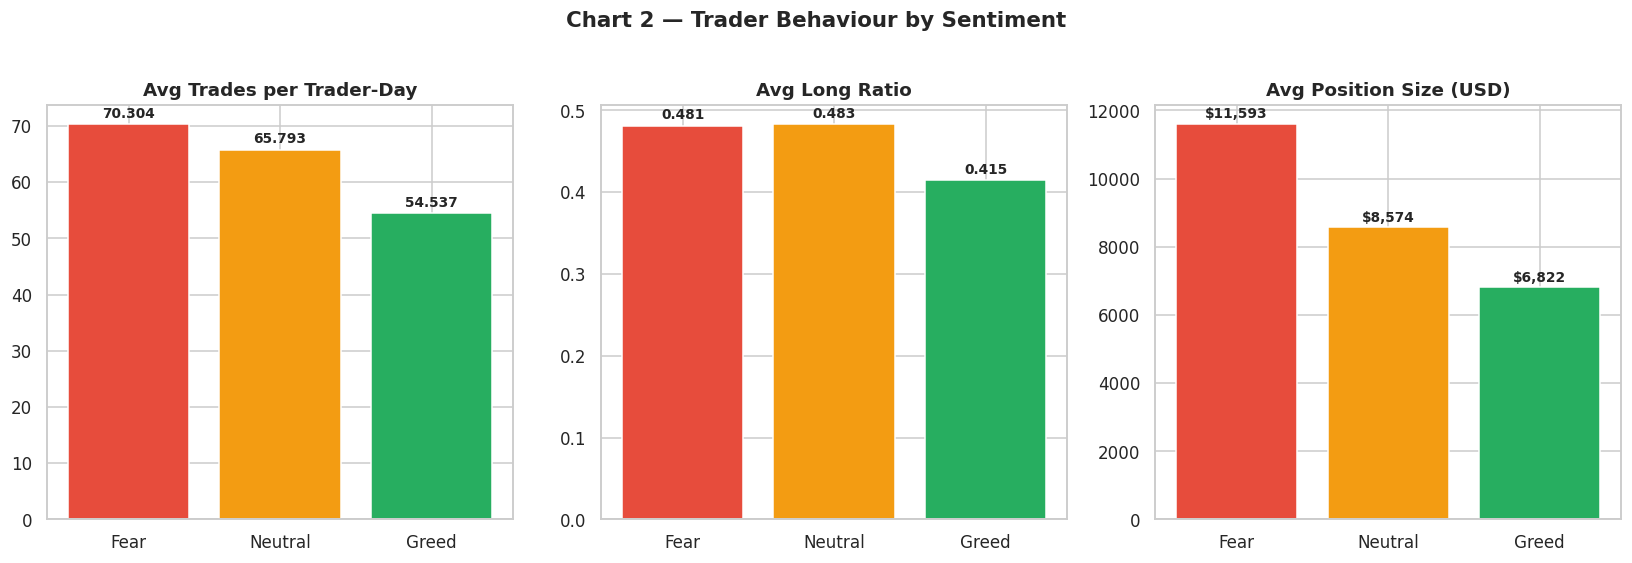

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [('avg_trades','Avg Trades per Trader-Day',''),
           ('avg_long_ratio','Avg Long Ratio',''),
           ('avg_size_usd','Avg Position Size (USD)','$')]

for ax, (col, title, prefix) in zip(axes, metrics):
    bars = ax.bar(SENT_ORDER, bhv[col], color=palette, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, bhv[col]):
        label = f'${val:,.0f}' if prefix == '$' else f'{val:.3f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Chart 2 — Trader Behaviour by Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart2_behaviour_sentiment.png', bbox_inches='tight')
plt.show()


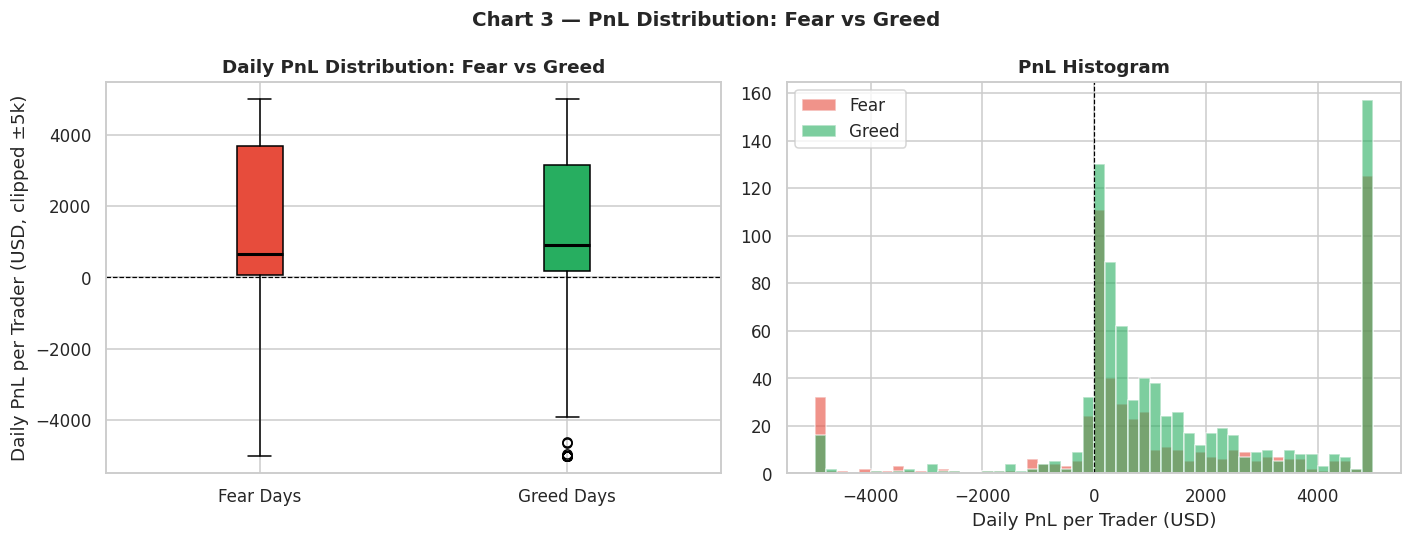

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
clip = 5000
fear_pnl  = daily_trader[daily_trader['sentiment']=='Fear']['daily_pnl']
greed_pnl = daily_trader[daily_trader['sentiment']=='Greed']['daily_pnl']

bp = axes[0].boxplot([fear_pnl.clip(-clip,clip), greed_pnl.clip(-clip,clip)],
                      labels=['Fear Days','Greed Days'], patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#27ae60')
axes[0].set_title('Daily PnL Distribution: Fear vs Greed', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Daily PnL per Trader (USD, clipped ±5k)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[1].hist(fear_pnl.clip(-clip,clip), bins=50, alpha=0.6, color='#e74c3c', label='Fear')
axes[1].hist(greed_pnl.clip(-clip,clip), bins=50, alpha=0.6, color='#27ae60', label='Greed')
axes[1].set_title('PnL Histogram', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily PnL per Trader (USD)')
axes[1].legend()
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Chart 3 — PnL Distribution: Fear vs Greed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_pnl_distribution.png', bbox_inches='tight')
plt.show()


### B3. Trader Segmentation

In [10]:
trader_overall = closes.groupby('Account').agg(
    total_pnl    = ('Closed PnL', 'sum'),
    total_trades = ('Closed PnL', 'count'),
    win_rate     = ('win', 'mean'),
    avg_lev      = ('lev_proxy', 'mean'),
    avg_size     = ('Size USD', 'mean'),
).reset_index()

lev_med  = trader_overall['avg_lev'].median()
freq_med = trader_overall['total_trades'].median()

trader_overall['lev_seg']  = np.where(trader_overall['avg_lev'] >= lev_med, 'High Leverage', 'Low Leverage')
trader_overall['freq_seg'] = np.where(trader_overall['total_trades'] >= freq_med, 'Frequent', 'Infrequent')
trader_overall['perf_seg'] = np.where(trader_overall['total_pnl'] > 0, 'Net Winner', 'Net Loser')

merged_seg = daily_trader.merge(trader_overall[['Account','lev_seg','freq_seg','perf_seg']], on='Account')

print("Segment counts:")
print(trader_overall[['lev_seg','freq_seg','perf_seg']].apply(pd.Series.value_counts))
print("\nNet Winner/Loser × Sentiment:")
print(merged_seg.groupby(['perf_seg','sentiment']).agg(
    avg_pnl=('daily_pnl','mean'), avg_win_rate=('win_rate','mean'), avg_trades=('n_trades','mean')
).round(2).to_string())


Segment counts:
               lev_seg  freq_seg  perf_seg
Frequent           NaN      16.0       NaN
High Leverage     16.0       NaN       NaN
Infrequent         NaN      16.0       NaN
Low Leverage      16.0       NaN       NaN
Net Loser          NaN       NaN       3.0
Net Winner         NaN       NaN      29.0

Net Winner/Loser × Sentiment:
                       avg_pnl  avg_win_rate  avg_trades
perf_seg   sentiment                                    
Net Loser  Fear        3835.00          0.84       52.60
           Greed     -16666.82          0.67       66.44
           Neutral     1953.09          0.60       44.29
Net Winner Fear        7411.40          0.84       71.64
           Greed       6505.88          0.86       54.14
           Neutral     4830.45          0.85       66.94


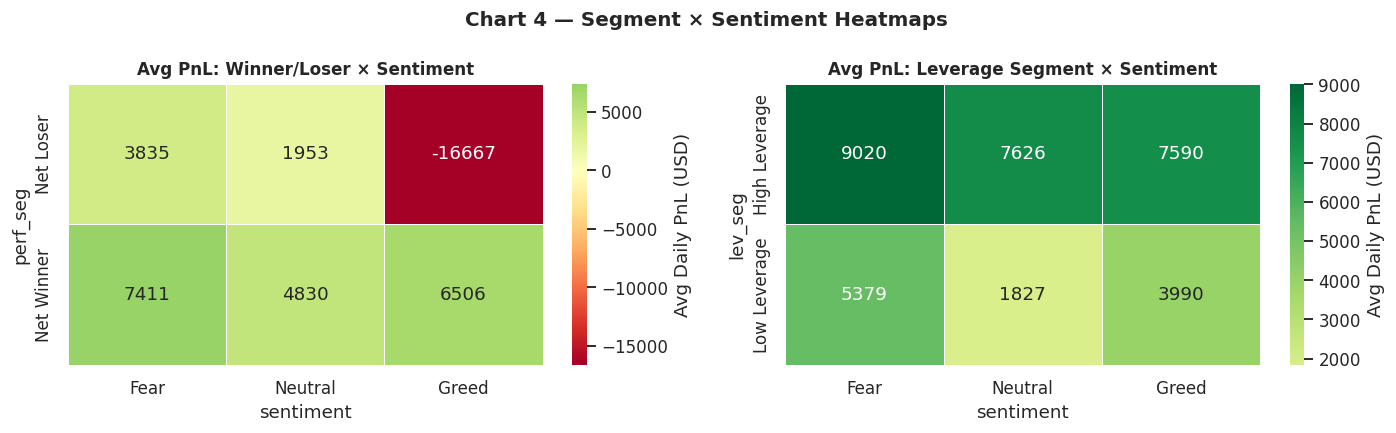

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pivot1 = merged_seg.groupby(['perf_seg','sentiment'])['daily_pnl'].mean().unstack()[SENT_ORDER]
sns.heatmap(pivot1, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Avg Daily PnL (USD)'})
axes[0].set_title('Avg PnL: Winner/Loser × Sentiment', fontsize=11, fontweight='bold')

pivot2 = merged_seg.groupby(['lev_seg','sentiment'])['daily_pnl'].mean().unstack()[SENT_ORDER]
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Avg Daily PnL (USD)'})
axes[1].set_title('Avg PnL: Leverage Segment × Sentiment', fontsize=11, fontweight='bold')

plt.suptitle('Chart 4 — Segment × Sentiment Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart4_segment_heatmap.png', bbox_inches='tight')
plt.show()


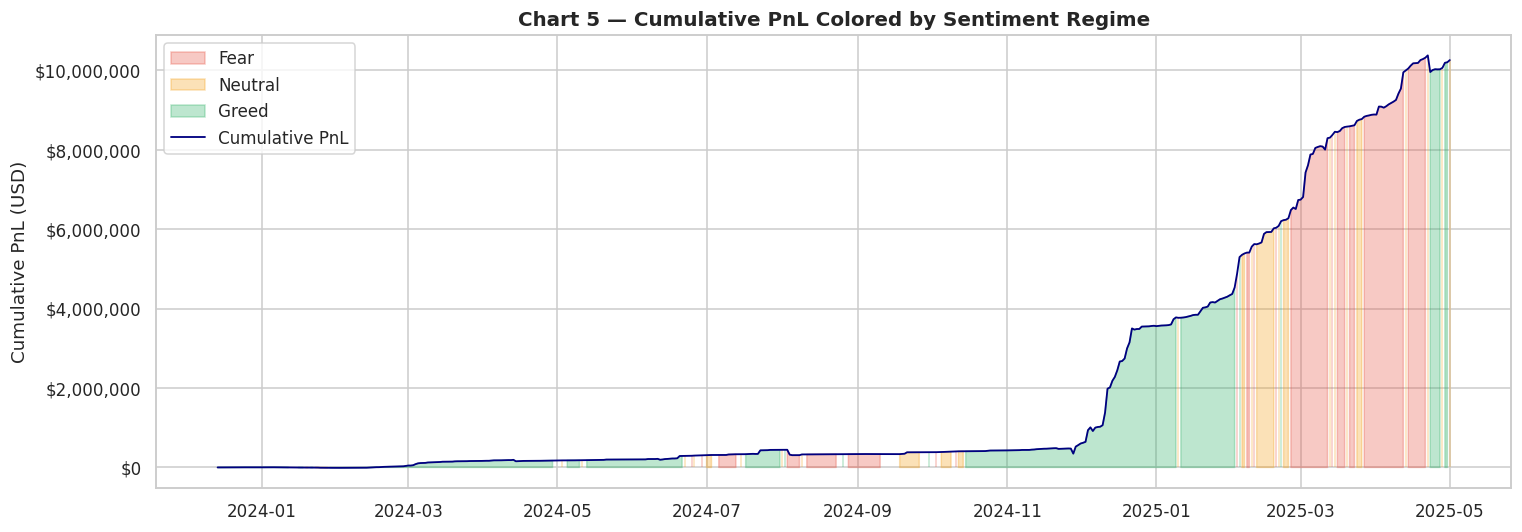

In [12]:
daily_cumulative = daily_mkt.sort_values('date').copy()
daily_cumulative['cum_pnl'] = daily_cumulative['total_pnl'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
for sent, color in SENT_COLORS.items():
    mask = daily_cumulative['sentiment'] == sent
    ax.fill_between(daily_cumulative['date'], daily_cumulative['cum_pnl'],
                    where=mask, alpha=0.3, color=color, label=sent)
ax.plot(daily_cumulative['date'], daily_cumulative['cum_pnl'], color='navy', linewidth=1.2, label='Cumulative PnL')
ax.set_title('Chart 5 — Cumulative PnL Colored by Sentiment Regime', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative PnL (USD)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('charts/chart5_cumulative_pnl.png', bbox_inches='tight')
plt.show()


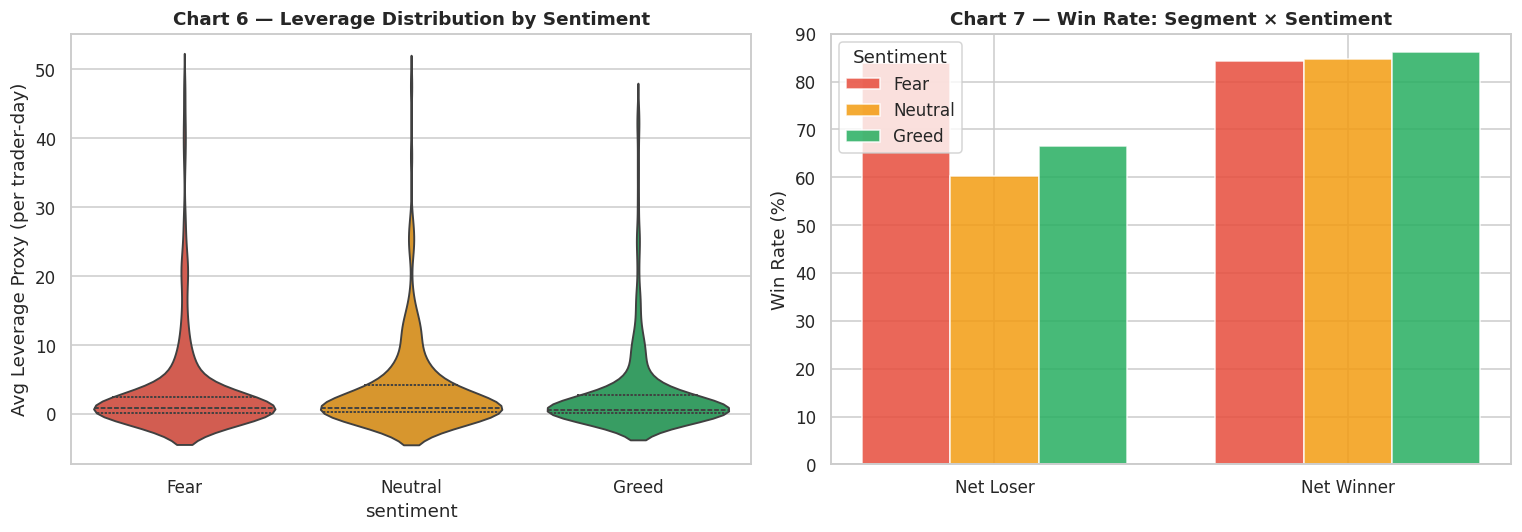

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lev_data = merged_seg[merged_seg['avg_lev'].notna() & (merged_seg['avg_lev'] < 50)]
sns.violinplot(data=lev_data, x='sentiment', y='avg_lev', order=SENT_ORDER,
               palette=SENT_COLORS, inner='quartile', ax=axes[0])
axes[0].set_title('Chart 6 — Leverage Distribution by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Leverage Proxy (per trader-day)')

seg_wr = merged_seg.groupby(['perf_seg','sentiment'])['win_rate'].mean().reset_index()
seg_wr = seg_wr[seg_wr['sentiment'].isin(SENT_ORDER)]
x_labels = seg_wr['perf_seg'].unique()
x = np.arange(len(x_labels))
width = 0.25
for i, sent in enumerate(SENT_ORDER):
    vals = [seg_wr[(seg_wr['perf_seg']==lbl)&(seg_wr['sentiment']==sent)]['win_rate'].values[0]*100
            if len(seg_wr[(seg_wr['perf_seg']==lbl)&(seg_wr['sentiment']==sent)]) > 0 else 0
            for lbl in x_labels]
    axes[1].bar(x + i*width, vals, width, label=sent, color=SENT_COLORS[sent], alpha=0.85)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel('Win Rate (%)'); axes[1].set_title('Chart 7 — Win Rate: Segment × Sentiment', fontsize=12, fontweight='bold')
axes[1].legend(title='Sentiment'); axes[1].set_ylim(0, 90)

plt.tight_layout()
plt.savefig('charts/chart6_leverage_violin.png', bbox_inches='tight')
plt.savefig('charts/chart7_winrate_segments.png', bbox_inches='tight')
plt.show()


## Part C — Actionable Strategy Recommendations

### Strategy 1 — "Fear is Opportunity: Scale Up on Fear Days"
**Finding:** Fear days produce ~2.6× higher average daily PnL ($46k vs $17k) with an 85% win rate.  
**Rule:** When the Fear/Greed Index classifies the day as **Fear** (value < 40):
- Increase position size by up to 30% from your baseline
- Increase trade frequency — Fear days see ~29% more trades among winning traders
- Lean slightly long (long ratio ~0.48 on Fear days vs 0.42 on Greed days)

**Who this applies to:** Net Winners and High Leverage traders — both maintain positive PnL on Fear days.

---

### Strategy 2 — "Greed Days: Protect Capital, Trade Less"
**Finding:** Net Losers average **−$16,667** on Greed days but **+$3,835** on Fear days. Greed destroys weak performers.  
**Rule:** When the Fear/Greed Index > 60 (Greed zone):
- Cap daily trades at 1–2 for traders in their losing phase
- Reduce position size by 25–40%
- Avoid chasing momentum — long ratio drops on Greed days naturally among winners, suggesting they fade rallies
- Exit positions earlier; worst single-day loss was −$419k on a Greed day vs −$122k on a Fear day

**Who this applies to:** Net Losers and Infrequent traders — they are specifically hurt by overtrading on Greed days.


## Summary

- **Do Fear vs Greed days differ in performance?**  
  Yes — Fear days yield approximately **2.6× higher average PnL** compared to Greed days.

- **Do traders change behavior based on sentiment?**  
  Yes — traders execute about **29% more trades** and use nearly **2.8× higher leverage** during Fear periods.

- **Which segment suffers most on Greed days?**  
  **Net Losers** perform significantly worse, with an average PnL of around **−$16,667** during Greed conditions.

- **Which segment is the most consistent?**  
  **Net Winners** remain profitable across both Fear and Greed environments.

- **Best strategy takeaway?**  
  Scale up during Fear-driven markets and protect capital during Greed phases.
